In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import heatmap ,histplot,violinplot
df = pd.read_csv('../data/处理后的数据2.csv')
df

,用户编号,生日,性别,订单号,二级分类,一级分类,属性,购买数量,购买日期,购买时年龄
0,786295544,NaN,NaN,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,2014-09-19,NaN
1,532110457,NaN,NaN,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,2013-10-11,NaN
2,249013725,NaN,NaN,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,2013-10-11,NaN
3,917056007,NaN,NaN,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,2014-10-23,NaN
4,444069173,NaN,NaN,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,2014-11-03,NaN
...,...,...,...,...,...,...,...,...,...,...
29928,57747284,NaN,NaN,35169635909,50010549,50008168,21458:125202070;22019:3228688;22019:3248884;22...,1,2014-01-09,NaN
29929,287541325,NaN,NaN,19778523000,50007011,50008168,21458:112788583;1633959:3523439;3130834:209537...,2,2014-01-09,NaN
29930,82915321,NaN,NaN,12766532512,50011993,28,21475:137325;1628665:3233937;1628665:29798;162...,1,2013-10-08,NaN
29931,78259523,NaN,NaN,18309305134,50013711,50008168,21458:30992;1628665:29778;1628665:29793;163395...,1,2013-10-08,NaN


In [7]:
# 不同年龄对于商品购买数量总和的分布和贡献比例的分布
df.购买日期=pd.to_datetime(df.购买日期)
df=df.query('购买时年龄.notna()')
#np.abs(np.clip(df.购买时年龄.round(0),0,7)).value_counts()
df['年龄段']=pd.Series(np.abs(np.clip(df.购买时年龄.round(0),0,7)))
#df.年龄段.unique()
a=df.groupby('年龄段').购买数量.sum().rename('购买').to_frame()
a=a.assign(累计销量=a.购买.cumsum()).eval('比例=累计销量/购买.sum()*100')
a

C:\Users\123\AppData\Local\Temp\ipykernel_26512\3966861355.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['年龄段']=pd.Series(np.abs(np.clip(df.购买时年龄.round(0),0,7)))


,购买,累计销量,比例
年龄段,,,
0.0,429,429,28.039216
1.0,505,934,61.045752
2.0,268,1202,78.562092
3.0,127,1329,86.862745
4.0,85,1414,92.418301
5.0,59,1473,96.274510
6.0,32,1505,98.366013
7.0,25,1530,100.000000


array([[<Axes: title={'center': '购买'}, xlabel='年龄段'>,
        <Axes: title={'center': '比例'}, xlabel='年龄段'>]], dtype=object)

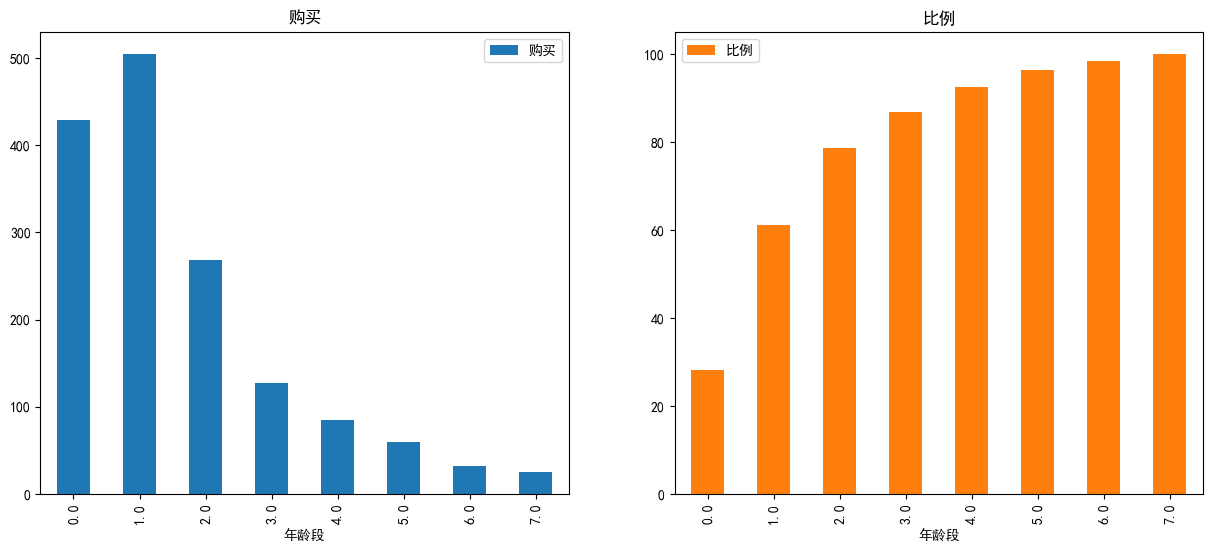

In [8]:
#实现不同年龄对于商品购买数量总和的分布和贡献比例的分布柱状图
a.drop('累计销量',axis=1).plot.bar(figsize=(15,6),subplots=True, layout=(1 ,2))

In [9]:
#实现不同年龄对于一级分类商品的贡献比较
data=df.groupby(['一级分类''年龄段').购买数量.sum().unstack()data.assign(合计=data.sum(axis=1)).sort_values('合计',ascending=False).drop(columns='合计').plot.bar()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (1461522285.py, line 2)

In [ ]:
# 实现按月份统计购买数量
df= pd.read_csv('../data/处理后的数据2.csv')
df.购买日期=pd.to_datetime(df.购买日期)
df.groupby([df.购买日期.dt.year,df.购买日期.dt.month]).购买数量.sum().unstack(0).iloc[:,1:3].plot.bar(rot=0)

In [ ]:
df = pd.read_csv('../data/处理后的数据2.csv')
df.购买日期=pd.to_datetime(df.购买日期)
data=df.groupby('二级分类').购买数.sum().sort_values(ascending=False)
data=df[df.二级分类.isin(data[data>500].index)].groupby([df.购买日期.dt.year,df.购买日期.dt.month,'二级分类'])\
    .购买数量.sum().unstack().rename_axis(index=['年''月'])

data.plot.bar(figsize=(15,10*16),subplots=True,layout=(16,1),sharex=False)